# Allan Deviation Plot from InfluxDB Frequency Counter Data

This notebook queries frequency data from InfluxDB and computes the **Allan Deviation (ADEV)**, a standard measure of frequency stability used in oscillator and clock characterization.

## 1. Install Dependencies

In [ ]:
# Uncomment and run if needed
%pip install influxdb pandas numpy allantools matplotlib

## 2. Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import allantools
from influxdb import InfluxDBClient

print('All imports successful.')

All imports successful.


## 3. Configuration

In [56]:
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ── InfluxDB connection ──────────────────────────────────────────────────────
INFLUX_HOST     = '192.168.100.12'       # Change if InfluxDB is on another host
INFLUX_PORT     = 8086
INFLUX_DB       = 'allan_db'
INFLUX_USER     = ''                # Leave empty if auth is disabled
INFLUX_PASSWORD = ''

# ── Measurement / series ────────────────────────────────────────────────────
MEASUREMENT     = 'frequency_counter'
RUN_NAME        = '0x6'        # Matches the tag run_name

# ── Counter parameters ──────────────────────────────────────────────────────
GATE_TIME_S     = 1.0             # 100 ms gate time → τ₀ = 0.1 s
NOMINAL_FREQ_HZ = 10e6              # Set e.g. 10e6 to normalise to fractional
                                    # frequency; None keeps units in Hz

# ── Plot options ────────────────────────────────────────────────────────────
PLOT_OHMS       = True              # Overlapping ADEV (more averaging, recommended)
PLOT_ADEV       = True              # Classic non-overlapping ADEV
CONFIDENCE_FILL = True              # Shaded 1-σ confidence interval

## 4. Query InfluxDB

In [74]:
client = InfluxDBClient(
    host=INFLUX_HOST,
    port=INFLUX_PORT,
    username=INFLUX_USER,
    password=INFLUX_PASSWORD,
    database=INFLUX_DB,
    ssl=True,
    verify_ssl=False
)

query = f"""
SELECT sample_number, frequency_hz
FROM "{MEASUREMENT}"
WHERE "run_name" = '{RUN_NAME}'
ORDER BY time ASC
"""

result = client.query(query)
points = list(result.get_points())

df = pd.DataFrame(points)
print(f'Loaded {len(df)} samples')
df.head()

Loaded 28000 samples


,time,sample_number,frequency_hz
0,2026-03-08T13:26:53.549140Z,1,10000000.0
1,2026-03-08T13:26:54.579448Z,2,10000000.0
2,2026-03-08T13:26:55.596059Z,3,10000000.0
3,2026-03-08T13:26:56.613484Z,4,10000000.0
4,2026-03-08T13:26:57.632501Z,5,10000000.0


## 5. Prepare Frequency Data

In [75]:
# Sort by sample number just in case
df = df.sort_values('sample_number').reset_index(drop=True)

freq = df['frequency_hz'].to_numpy(dtype=float)

# Optional: convert to fractional frequency deviation y = (f - f₀) / f₀
if NOMINAL_FREQ_HZ is not None:
    data = (freq - NOMINAL_FREQ_HZ) / NOMINAL_FREQ_HZ
    y_label = 'Allan Deviation (fractional frequency)'
    data_type = 'freq'
    print(f'Using fractional frequency deviation  (f₀ = {NOMINAL_FREQ_HZ:.6e} Hz)')
else:
    data = freq
    y_label = 'Allan Deviation (Hz)'
    data_type = 'freq'
    print('Using absolute frequency (Hz)')

print(f'Samples        : {len(data)}')
print(f'Gate time τ₀   : {GATE_TIME_S*1000:.1f} ms')
print(f'Total span     : {len(data)*GATE_TIME_S:.1f} s  ({len(data)*GATE_TIME_S/60:.2f} min)')
print(f'Mean frequency : {np.mean(freq):.6f} Hz')
print(f'Std  frequency : {np.std(freq):.6f} Hz')

Using fractional frequency deviation  (f₀ = 1.000000e+07 Hz)
Samples        : 28000
Gate time τ₀   : 1000.0 ms
Total span     : 28000.0 s  (466.67 min)
Mean frequency : 10000000.075107 Hz
Std  frequency : 3.873569 Hz


## 6. Compute Allan Deviation

In [76]:
rate = 1.0 / GATE_TIME_S   # samples per second

results = {}

if PLOT_OHMS:
    (taus_o, adev_o, adev_err_o, ns_o) = allantools.oadev(
        data, rate=rate, data_type=data_type, taus='decade'
    )
    results['OADEV'] = (taus_o, adev_o, adev_err_o)

if PLOT_ADEV:
    (taus_a, adev_a, adev_err_a, ns_a) = allantools.adev(
        data, rate=rate, data_type=data_type, taus='decade'
    )
    results['ADEV'] = (taus_a, adev_a, adev_err_a)

print('Allan Deviation computed successfully.')
if PLOT_OHMS:
    print(f'  OADEV: {len(taus_o)} τ points from {taus_o[0]:.3f} s to {taus_o[-1]:.1f} s')
if PLOT_ADEV:
    print(f'  ADEV : {len(taus_a)} τ points from {taus_a[0]:.3f} s to {taus_a[-1]:.1f} s')

Allan Deviation computed successfully.
  OADEV: 13 τ points from 1.000 s to 10000.0 s
  ADEV : 12 τ points from 1.000 s to 4000.0 s


## 7. Plot Allan Deviation

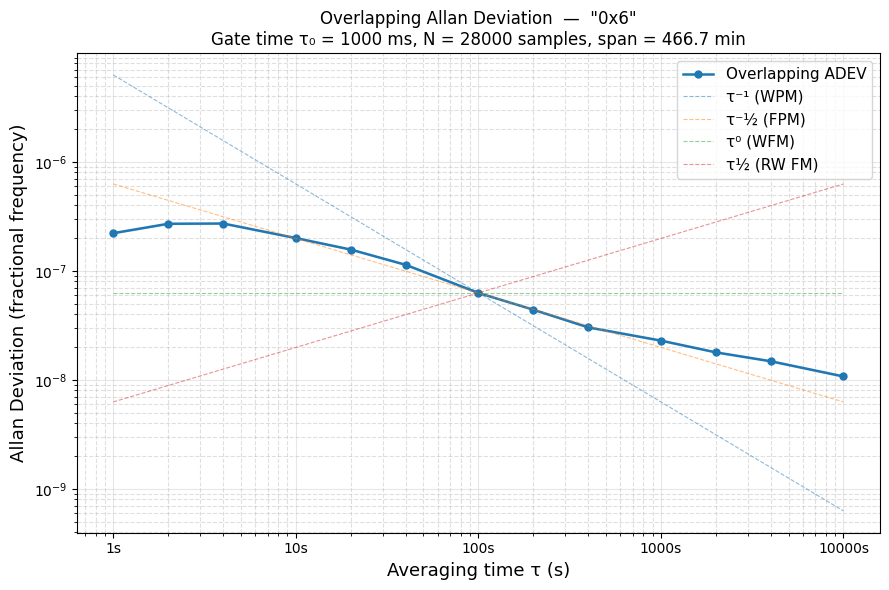

Plot saved to allan_deviation.png


In [77]:
fig, ax = plt.subplots(figsize=(9, 6))

# ── Plot OADEV only ──────────────────────────────────────────────────────────
ax.loglog(taus_o, adev_o, marker='o', markersize=5,
          linewidth=1.8, color='#1f77b4', label='Overlapping ADEV')
if CONFIDENCE_FILL:
    ax.fill_between(taus_o,
                    np.maximum(adev_o - adev_err_o, 1e-30),
                    adev_o + adev_err_o,
                    alpha=0.18, color='#1f77b4')

# ── Slope reference lines ────────────────────────────────────────────────────
tau_ref = np.array([taus_o[0], taus_o[-1]])
mid_tau = np.sqrt(tau_ref[0] * tau_ref[-1])
mid_val = np.interp(mid_tau, taus_o, adev_o)
for exp, lbl in [(-1, 'τ⁻¹ (WPM)'), (-0.5, 'τ⁻½ (FPM)'),
                  (0, 'τ⁰ (WFM)'), (0.5, 'τ½ (RW FM)')]:
    ax.loglog(tau_ref, mid_val * (tau_ref / mid_tau)**exp,
              ls='--', lw=0.8, alpha=0.5, label=lbl)

# ── Formatting ───────────────────────────────────────────────────────────────
ax.set_xlabel('Averaging time τ (s)', fontsize=13)
ax.set_ylabel(y_label, fontsize=13)
ax.set_title(f'Overlapping Allan Deviation  —  "{RUN_NAME}"\n'
             f'Gate time τ₀ = {GATE_TIME_S*1000:.0f} ms, '
             f'N = {len(data)} samples, '
             f'span = {len(data)*GATE_TIME_S/60:.1f} min',
             fontsize=12)

ax.grid(True, which='both', ls='--', alpha=0.4)
ax.grid(True, which='major', ls='-',  alpha=0.3)
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}s'))
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

plt.tight_layout()
plt.savefig('allan_deviation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to allan_deviation.png')

In [78]:
## 8. Print Summary Table

In [73]:
if PLOT_OHMS:
    summary = pd.DataFrame({
        'τ (s)':     taus_o,
        'OADEV':     adev_o,
        '±1σ':       adev_err_o,
    })
    print('Overlapping Allan Deviation summary:')
    display(summary.style.format({'τ (s)': '{:.4f}', 'OADEV': '{:.4e}', '±1σ': '{:.4e}'}))

Overlapping Allan Deviation summary:


,τ (s),OADEV,±1σ
0,1.0000,2.4721e-07,1.6692e-09
1,2.0000,3.0208e-07,2.0399e-09
2,4.0000,3.0467e-07,2.0575e-09
3,10.0000,2.2441e-07,1.5159e-09
4,20.0000,1.7611e-07,1.1902e-09
5,40.0000,1.2758e-07,8.6303e-10
6,100.0000,7.0416e-08,4.7763e-10
7,200.0000,4.9548e-08,3.3764e-10
8,400.0000,3.4125e-08,2.3473e-10
9,1000.0000,2.6019e-08,1.8428e-10
